In [ ]:
!pip install google-api-python-client
!pip install nltk
!pip install scikit-learn
!pip install pandas
!pip install matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd

df = pd.read_csv("/content/IMDB_Dataset.csv", engine='python', on_bad_lines='skip')

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
print(df.shape)

(50917, 2)


In [ ]:
# Convert Labels into Numbers
df['sentiment'] = df['sentiment'].str.lower()

df['sentiment'] = df['sentiment'].str.strip()

df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

Text Preprocessing

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    filtered_words = [word for word in words if word not in stop_words]

    # Join words again
    text = " ".join(filtered_words)

    return text

Apply Cleaning to Dataset

In [ ]:
df['cleaned_review'] = df['review'].apply(clean_text)
print(df)

                                                  review  sentiment  \
0      One of the other reviewers has mentioned that ...          1   
1      A wonderful little production. <br /><br />The...          1   
2      I thought this was a wonderful way to spend ti...          1   
3      Basically there's a family where a little boy ...          0   
4      Petter Mattei's "Love in the Time of Money" is...          1   
...                                                  ...        ...   
50912  I thought this movie did a down right good job...          1   
50913  Bad plot, bad dialogue, bad acting, idiotic di...          0   
50914  I am a Catholic taught in parochial elementary...          0   
50915  I'm going to have to disagree with the previou...          0   
50916  No one expects the Star Trek movies to be high...          0   

                                          cleaned_review  
0      one reviewers mentioned watching 1 oz episode ...  
1      wonderful little produ

Convert Text Into Numbers Using TF-IDF

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_review'])

y = df['sentiment']

Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Training Logistic Legression Model

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Model Prediction

In [ ]:
y_pred = model.predict(X_test)

Checking Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8898271798900236


In [ ]:
sample_comment = ["This tutorial is very bad"]

# Clean text
cleaned = [clean_text(comment) for comment in sample_comment]

# Convert to TF-IDF
vectorized = vectorizer.transform(cleaned)

# Predict sentiment
prediction = model.predict(vectorized)

if prediction[0] == 1:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

Negative Sentiment


In [ ]:
from googleapiclient.discovery import build

In [ ]:
api_key = "My_API_Key"

youtube = build(
    'youtube',
    'v3',
    developerKey=api_key
)

In [ ]:
# https://youtu.be/rmjSU65vIPQ?si=hLVqwUAxzpB5aKde
video_id = "gELNZpmyqAI"
request = youtube.commentThreads().list(
    part='snippet',
    videoId=video_id,
    maxResults=20
)

response = request.execute()

In [ ]:
comments = []

for item in response['items']:

    comment = item['snippet']['topLevelComment']['snippet']['textDisplay']

    comments.append(comment)

print(comments)

['बहुत सुंदर मूवी हैं', '2 Part kab daloge', 'Isliye ye movie bar bar mere feed me arahe the , ek dam master peace', 'I like Full support super❤❤❤❤❤❤❤❤❤👍👍👍👍✌✌👌👌👌', 'The acting was superb❤', 'This movie made me emotional', 'Bahut achhi movie hai sabko dekhna chahiye 😊', 'Very nice movie👍🏼', 'Very interesting movie 😊', 'Kya movie hai 👍', 'Mere do betiya he hanu or vaviya or mene shi fhesla liya he ki aage santan nhi krunga 😊', 'Luv ranjan is bar thoda hat ke...kya baat hai', 'Bsdk sara kram kand karke mera hi nam rakhna tha😢', 'NYC movie', 'Police mujrim ko chorti naheen hai<br>Patal se bhi Nikal lati hai  magar kabhi kabhi Zalim ka Sar Kuchalnay k liye Thora Sa Case ko idhar udhar karke &quot; VADH&quot; karnay walay kisi Qatil magar Mazloom Master ji ko koi Great Officer Bacha le jata hai Taki &quot; Khas Kam or Jahan Pak &quot; rahay  <br>Rashid Raza from Hyderabad Pakistan 🇵🇰', 'Super', 'Bahut acchi movie he', 'Bhai aeisamladka kisi ko na de', 'If I have a son like that, I will consi

Predict Sentiment for YouTube Comments

In [ ]:
for comment in comments:

    # Clean comment
    cleaned = clean_text(comment)

    # Convert into TF-IDF vector
    vectorized = vectorizer.transform([cleaned])

    # Predict sentiment
    prediction = model.predict(vectorized)

    # Display result
    if prediction[0] == 1:
        print("Positive →", comment)
    else:
        print("Negative →", comment)

Negative → बहुत सुंदर मूवी हैं
Negative → 2 Part kab daloge
Negative → Isliye ye movie bar bar mere feed me arahe the , ek dam master peace
Positive → I like Full support super❤❤❤❤❤❤❤❤❤👍👍👍👍✌✌👌👌👌
Positive → The acting was superb❤
Positive → This movie made me emotional
Negative → Bahut achhi movie hai sabko dekhna chahiye 😊
Positive → Very nice movie👍🏼
Negative → Very interesting movie 😊
Negative → Kya movie hai 👍
Positive → Mere do betiya he hanu or vaviya or mene shi fhesla liya he ki aage santan nhi krunga 😊
Negative → Luv ranjan is bar thoda hat ke...kya baat hai
Negative → Bsdk sara kram kand karke mera hi nam rakhna tha😢
Positive → NYC movie
Positive → Police mujrim ko chorti naheen hai<br>Patal se bhi Nikal lati hai  magar kabhi kabhi Zalim ka Sar Kuchalnay k liye Thora Sa Case ko idhar udhar karke &quot; VADH&quot; karnay walay kisi Qatil magar Mazloom Master ji ko koi Great Officer Bacha le jata hai Taki &quot; Khas Kam or Jahan Pak &quot; rahay  <br>Rashid Raza from Hyderabad 

Count Positive and Negative Comments

In [ ]:
positive = 0
negative = 0

for comment in comments:

    cleaned = clean_text(comment)

    vectorized = vectorizer.transform([cleaned])

    prediction = model.predict(vectorized)

    if prediction[0] == 1:
        positive += 1
    else:
        negative += 1

print("Positive Comments:", positive)
print("Negative Comments:", negative)

Positive Comments: 10
Negative Comments: 10


Create Pie Chart Visualization

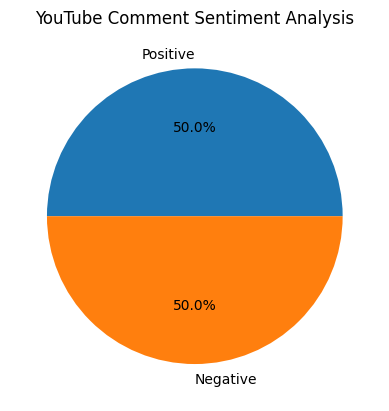

In [ ]:
labels = ['Positive', 'Negative']

sizes = [positive, negative]

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("YouTube Comment Sentiment Analysis")

plt.show()